TASK 1.1 — MDP Setup Verification

Transition probability row-sums (each must = 1.0):
  P[High     , Search, :] = 1.0000
  P[High     , Wait  , :] = 1.0000
  P[Low      , Search, :] = 1.0000
  P[Low      , Wait  , :] = 1.0000
  P[Charging , Search, :] = 0.0000
  P[Charging , Wait  , :] = 1.0000

Reward matrix R[s, a]:
                Search      Wait
  High            4.00      1.00
  Low             1.20      1.00
  Charging        0.00      0.00

TASK 1.2 — Policy Evaluation
  Policy: High→Search, Low→Wait, Charging→Wait
  → Converged in 133 iterations

  Value function Vπ(s):
    Vπ(High     ) = 18.108100
    Vπ(Low      ) = 9.999992
    Vπ(Charging ) = 16.297289


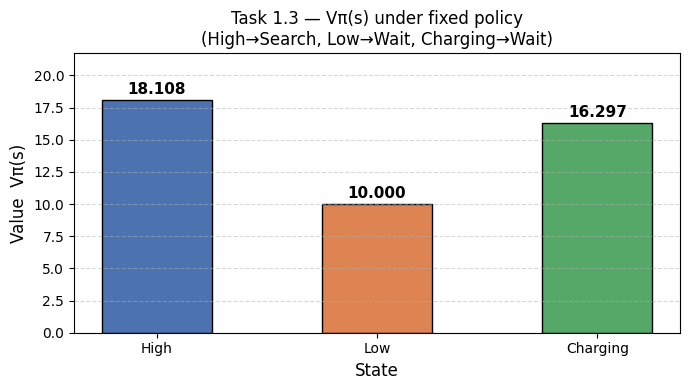

  [Saved] task1_policy_evaluation.png

TASK 2.1 — Value Iteration
  → Converged in 142 iterations

  Optimal value function V*(s):
    V*(High     ) = 29.643827
    V*(Low      ) = 25.808210
    V*(Charging ) = 26.679443

  Optimal Policy π*(s) from Value Iteration:
    π*(High     ) = Search
    π*(Low      ) = Search
    π*(Charging ) = Wait


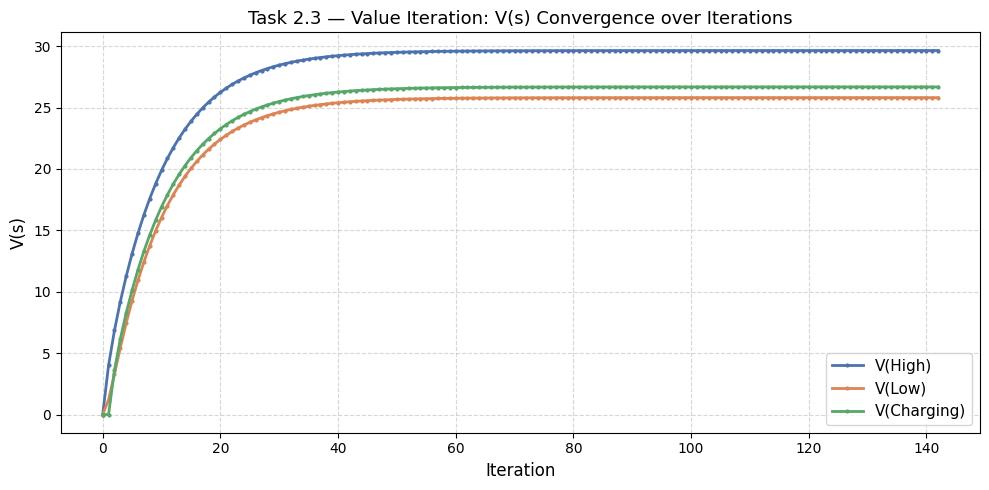

  [Saved] task2_value_iteration_convergence.png

TASK 3.2 — Policy Iteration

  ── Outer Iteration 1 ──────────────────
  Current policy : ['Wait', 'Wait', 'Wait']
  → Converged in 133 iterations
  Vπ             : [10. 10.  9.]

  ── Outer Iteration 2 ──────────────────
  Current policy : ['Search', 'Search', 'Wait']
  → Converged in 142 iterations
  Vπ             : [29.6438 25.8082 26.6794]

  Policy is stable — converged after 2 outer iteration(s)!

  Optimal Policy π*(s) from Policy Iteration:
    π*(High     ) = Search
    π*(Low      ) = Search
    π*(Charging ) = Wait

  Optimal V*(s) from Policy Iteration:
    V*(High     ) = 29.643827
    V*(Low      ) = 25.808210
    V*(Charging ) = 26.679443


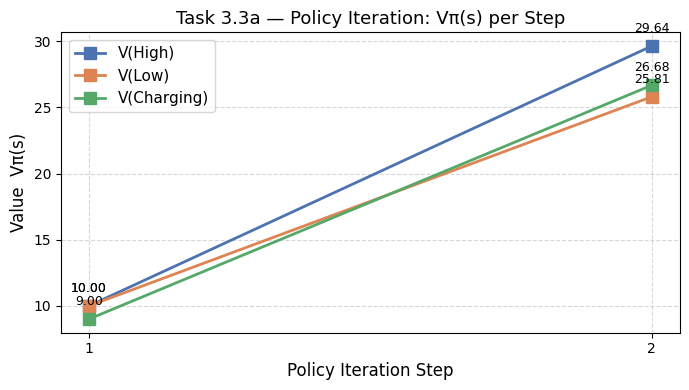

  [Saved] task3a_policy_iteration_values.png


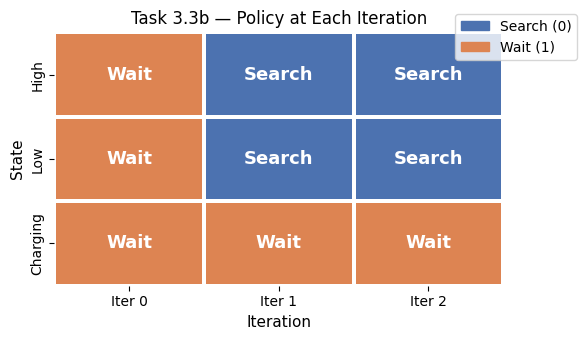

  [Saved] task3b_policy_heatmap.png

TASK 4 — Analysis and Interpretation

┌─────────────────────────────────────────────────────┐
│  4.1  Value Iteration vs Policy Iteration           │
├─────────────────────────────────────────────────────┤
│  Value Iteration  : 142 sweeps                      │
│  Policy Iteration :   2 outer iterations            │
└─────────────────────────────────────────────────────┘

  Value Iteration updates all states every sweep without
  committing to a policy — needs many sweeps to converge.
  Policy Iteration fully evaluates each policy before improving,
  so it makes fewer but more "informed" updates → much fewer
  outer iterations (typically 2–5 even for large MDPs).

┌─────────────────────────────────────────────────────┐
│  4.2  Convergence Behaviour                         │
└─────────────────────────────────────────────────────┘

  • All V(s) start at 0 and grow monotonically in Value
    Iteration because the Bellman operator is a contraction
    m

In [3]:
# ================================================================
#  MA3206 AI — Assignment 5  |  MDP: Policy & Value Iteration


import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# ================================================================
#  TASK 1.1 — Build the MDP
# ================================================================

STATES  = ['High', 'Low', 'Charging']   # index: 0, 1, 2
ACTIONS = ['Search', 'Wait']             # index: 0, 1

GAMMA = 0.9      # discount factor
THETA = 1e-6     # convergence threshold

# ── P[s, a, s'] = transition probability ─────────────────────────
P = np.zeros((3, 2, 3))

# High (s=0)
P[0, 0, 0] = 0.7   # High --Search--> High
P[0, 0, 1] = 0.3   # High --Search--> Low
P[0, 1, 0] = 1.0   # High --Wait---> High

# Low (s=1)
P[1, 0, 0] = 0.4   # Low --Search--> High  (recharge penalty)
P[1, 0, 1] = 0.6   # Low --Search--> Low
P[1, 1, 1] = 1.0   # Low --Wait---> Low

# Charging (s=2)  — only Wait is allowed
P[2, 1, 0] = 1.0   # Charging --Wait--> High

# ── R[s, a] = expected immediate reward ──────────────────────────
R = np.zeros((3, 2))

R[0, 0] = 4.0                        # High,     Search → +4
R[0, 1] = 1.0                        # High,     Wait   → +1
R[1, 0] = 0.4 * (-3) + 0.6 * (4)   # Low,      Search → 1.2 (expected)
R[1, 1] = 1.0                        # Low,      Wait   → +1
R[2, 0] = 0.0                        # Charging, Search → 0 (not allowed)
R[2, 1] = 0.0                        # Charging, Wait   → 0

# ── Verify ───────────────────────────────────────────────────────
print("=" * 55)
print("TASK 1.1 — MDP Setup Verification")
print("=" * 55)

print("\nTransition probability row-sums (each must = 1.0):")
for s, sname in enumerate(STATES):
    for a, aname in enumerate(ACTIONS):
        print(f"  P[{sname:9s}, {aname:6s}, :] = {P[s, a, :].sum():.4f}")

print("\nReward matrix R[s, a]:")
print(f"  {'':10s}  {'Search':>8s}  {'Wait':>8s}")
for s, sname in enumerate(STATES):
    print(f"  {sname:10s}  {R[s,0]:>8.2f}  {R[s,1]:>8.2f}")


# ================================================================
#  TASK 1.2 — Policy Evaluation
# ================================================================

def policy_evaluation(P, R, policy, gamma, theta):
    """
    Iterative Policy Evaluation.

    Applies the Bellman Expectation equation repeatedly:
        V(s) ← Σ_{s'} P(s'|s, π(s)) * [R(s, π(s)) + γ·V(s')]
    until max change < theta.

    Parameters
    ----------
    P      : ndarray (|S|, |A|, |S|) — transition probabilities
    R      : ndarray (|S|, |A|)      — expected immediate rewards
    policy : list/array of length |S| — policy[s] = action index
    gamma  : float — discount factor
    theta  : float — convergence threshold

    Returns
    -------
    V : ndarray (|S|,) — converged value function under this policy
    """
    n_states = len(STATES)
    V = np.zeros(n_states)      # initialise V(s) = 0 for all s
    iteration = 0

    while True:
        delta = 0
        V_new = np.zeros(n_states)

        for s in range(n_states):
            a = policy[s]
            # Bellman expectation backup
            V_new[s] = np.sum(P[s, a, :] * (R[s, a] + gamma * V))
            delta = max(delta, abs(V_new[s] - V[s]))

        V = V_new.copy()
        iteration += 1

        if delta < theta:
            break

    print(f"  → Converged in {iteration} iterations")
    return V


# Fixed policy: High→Search(0), Low→Wait(1), Charging→Wait(1)
fixed_policy = [0, 1, 1]

print("\n" + "=" * 55)
print("TASK 1.2 — Policy Evaluation")
print("=" * 55)
print("  Policy: High→Search, Low→Wait, Charging→Wait")

V_pi = policy_evaluation(P, R, fixed_policy, GAMMA, THETA)

print("\n  Value function Vπ(s):")
for s, sname in enumerate(STATES):
    print(f"    Vπ({sname:9s}) = {V_pi[s]:.6f}")


# ================================================================
#  TASK 1.3 — Bar Chart of Vπ(s)
# ================================================================

fig, ax = plt.subplots(figsize=(7, 4))
colors = ['#4C72B0', '#DD8452', '#55A868']
bars   = ax.bar(STATES, V_pi, color=colors, edgecolor='black', width=0.5)

for bar, val in zip(bars, V_pi):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.2,
            f"{val:.3f}",
            ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_xlabel("State", fontsize=12)
ax.set_ylabel("Value  Vπ(s)", fontsize=12)
ax.set_title("Task 1.3 — Vπ(s) under fixed policy\n"
             "(High→Search, Low→Wait, Charging→Wait)", fontsize=12)
ax.set_ylim(0, max(V_pi) * 1.2)
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig("task1_policy_evaluation.png", dpi=150)
plt.show()
print("  [Saved] task1_policy_evaluation.png")


# ================================================================
#  TASK 2.1 — Value Iteration
# ================================================================

def value_iteration(P, R, gamma, theta):
    """
    Value Iteration — finds optimal value function V*.

    Applies Bellman Optimality equation at every state:
        V(s) ← max_a  Σ_{s'} P(s'|s,a) * [R(s,a) + γ·V(s')]
    until max change < theta.

    Returns
    -------
    V       : converged V* array
    history : list of V snapshots after every iteration (for plotting)
    """
    n_states  = len(STATES)
    n_actions = len(ACTIONS)
    V         = np.zeros(n_states)
    history   = [V.copy()]
    iteration = 0

    while True:
        delta = 0
        V_new = np.zeros(n_states)

        for s in range(n_states):
            Q_s = np.zeros(n_actions)
            for a in range(n_actions):
                Q_s[a] = np.sum(P[s, a, :] * (R[s, a] + gamma * V))

            # Charging state: Search is not allowed → mask it
            if s == 2:
                Q_s[0] = -np.inf

            V_new[s] = np.max(Q_s)
            delta     = max(delta, abs(V_new[s] - V[s]))

        V = V_new.copy()
        history.append(V.copy())
        iteration += 1

        if delta < theta:
            break

    print(f"  → Converged in {iteration} iterations")
    return V, history


print("\n" + "=" * 55)
print("TASK 2.1 — Value Iteration")
print("=" * 55)

V_star, vi_history = value_iteration(P, R, GAMMA, THETA)

print("\n  Optimal value function V*(s):")
for s, sname in enumerate(STATES):
    print(f"    V*({sname:9s}) = {V_star[s]:.6f}")


# ================================================================
#  TASK 2.2 — Extract Optimal Policy
# ================================================================

def extract_policy(V_star, P, R, gamma):
    """
    Greedy policy extraction.
    For each state, pick the action with the highest Q(s,a) under V*.
    """
    n_states  = len(STATES)
    n_actions = len(ACTIONS)
    policy    = np.zeros(n_states, dtype=int)

    for s in range(n_states):
        Q_s = np.zeros(n_actions)
        for a in range(n_actions):
            Q_s[a] = np.sum(P[s, a, :] * (R[s, a] + gamma * V_star))

        if s == 2:          # Charging: Search not allowed
            Q_s[0] = -np.inf

        policy[s] = np.argmax(Q_s)

    return policy


optimal_policy_vi = extract_policy(V_star, P, R, GAMMA)

print("\n  Optimal Policy π*(s) from Value Iteration:")
for s, sname in enumerate(STATES):
    print(f"    π*({sname:9s}) = {ACTIONS[optimal_policy_vi[s]]}")


# ================================================================
#  TASK 2.3 — Convergence Plot
# ================================================================

vi_history_arr = np.array(vi_history)   # shape: (iterations+1, 3)

fig, ax = plt.subplots(figsize=(10, 5))
line_colors = ['#4C72B0', '#DD8452', '#55A868']

for s, (sname, col) in enumerate(zip(STATES, line_colors)):
    ax.plot(vi_history_arr[:, s], label=f"V({sname})",
            color=col, linewidth=2, marker='o', markersize=2)

ax.set_xlabel("Iteration", fontsize=12)
ax.set_ylabel("V(s)", fontsize=12)
ax.set_title("Task 2.3 — Value Iteration: V(s) Convergence over Iterations", fontsize=13)
ax.legend(fontsize=11)
ax.grid(linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig("task2_value_iteration_convergence.png", dpi=150)
plt.show()
print("  [Saved] task2_value_iteration_convergence.png")


# ================================================================
#  TASK 3.1 — Policy Improvement
# ================================================================

def policy_improvement(V, P, R, gamma, old_policy):
    """
    Greedy policy improvement step.

    For each state, compute Q(s,a) using V and pick the best action.
    Returns:
        new_policy : improved greedy policy
        stable     : True if policy did NOT change (convergence signal)
    """
    n_states  = len(STATES)
    n_actions = len(ACTIONS)
    new_policy = np.zeros(n_states, dtype=int)

    for s in range(n_states):
        Q_s = np.zeros(n_actions)
        for a in range(n_actions):
            Q_s[a] = np.sum(P[s, a, :] * (R[s, a] + gamma * V))

        if s == 2:          # Charging: Search not allowed
            Q_s[0] = -np.inf

        new_policy[s] = np.argmax(Q_s)

    stable = np.array_equal(new_policy, old_policy)
    return new_policy, stable


# ================================================================
#  TASK 3.2 — Full Policy Iteration Loop
# ================================================================

def policy_iteration(P, R, gamma, theta):
    """
    Full Policy Iteration.

    Alternates:
        1. policy_evaluation()  → Vπ for current policy
        2. policy_improvement() → greedy update

    Stops when policy is stable (no change between steps).

    Returns
    -------
    optimal_policy : final converged policy
    V_star         : final value function
    policy_history : list of policy arrays at each outer iteration
    V_history      : list of V arrays at each outer iteration
    """
    n_states = len(STATES)

    # Initial policy: all states → Wait (index 1)
    policy         = np.ones(n_states, dtype=int)
    policy_history = [policy.copy()]
    V_history      = []
    outer_iter     = 0

    print("\n" + "=" * 55)
    print("TASK 3.2 — Policy Iteration")
    print("=" * 55)

    while True:
        outer_iter += 1
        print(f"\n  ── Outer Iteration {outer_iter} ──────────────────")
        print(f"  Current policy : {[ACTIONS[a] for a in policy]}")

        # Step 1: Evaluate current policy
        V = policy_evaluation(P, R, policy, gamma, theta)
        V_history.append(V.copy())
        print(f"  Vπ             : {np.round(V, 4)}")

        # Step 2: Improve policy greedily
        new_policy, stable = policy_improvement(V, P, R, gamma, policy)
        policy = new_policy
        policy_history.append(policy.copy())

        if stable:
            print(f"\n  Policy is stable — converged after {outer_iter} outer iteration(s)!")
            break

    return policy, V_history[-1], policy_history, V_history


optimal_policy_pi, V_star_pi, pi_policy_hist, pi_V_hist = \
    policy_iteration(P, R, GAMMA, THETA)

print("\n  Optimal Policy π*(s) from Policy Iteration:")
for s, sname in enumerate(STATES):
    print(f"    π*({sname:9s}) = {ACTIONS[optimal_policy_pi[s]]}")

print("\n  Optimal V*(s) from Policy Iteration:")
for s, sname in enumerate(STATES):
    print(f"    V*({sname:9s}) = {V_star_pi[s]:.6f}")


# ================================================================
#  TASK 3.3a — Line Plot: Vπ(s) across Policy Iteration steps
# ================================================================

pi_V_arr = np.array(pi_V_hist)   # shape: (n_outer_iters, 3)

fig, ax = plt.subplots(figsize=(7, 4))
for s, (sname, col) in enumerate(zip(STATES, ['#4C72B0', '#DD8452', '#55A868'])):
    ax.plot(range(1, len(pi_V_arr) + 1), pi_V_arr[:, s],
            marker='s', markersize=9, linewidth=2,
            label=f"V({sname})", color=col)
    # Annotate each point
    for i, val in enumerate(pi_V_arr[:, s]):
        ax.annotate(f"{val:.2f}",
                    (i + 1, val),
                    textcoords="offset points",
                    xytext=(0, 10),
                    ha='center', fontsize=9)

ax.set_xlabel("Policy Iteration Step", fontsize=12)
ax.set_ylabel("Value  Vπ(s)", fontsize=12)
ax.set_title("Task 3.3a — Policy Iteration: Vπ(s) per Step", fontsize=13)
ax.legend(fontsize=11)
ax.set_xticks(range(1, len(pi_V_arr) + 1))
ax.grid(linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig("task3a_policy_iteration_values.png", dpi=150)
plt.show()
print("  [Saved] task3a_policy_iteration_values.png")


# ================================================================
#  TASK 3.3b — Heatmap: Policy at each iteration
# ================================================================

# policy_history has (n_outer_iters + 1) entries (includes initial + after each improvement)
policy_mat    = np.array(pi_policy_hist).T         # shape: (3 states, n_iters)
action_labels = np.where(policy_mat == 0, "Search", "Wait")

fig, ax = plt.subplots(figsize=(max(5, policy_mat.shape[1] * 2), 3.5))
sns.heatmap(policy_mat, ax=ax,
            cmap=['#4C72B0', '#DD8452'],
            linewidths=1.5, linecolor='white',
            annot=action_labels, fmt='',
            annot_kws={"size": 13, "weight": "bold", "color": "white"},
            cbar=False,
            xticklabels=[f"Iter {i}" for i in range(policy_mat.shape[1])],
            yticklabels=STATES)

patch_search = mpatches.Patch(color='#4C72B0', label='Search (0)')
patch_wait   = mpatches.Patch(color='#DD8452', label='Wait (1)')
ax.legend(handles=[patch_search, patch_wait],
          loc='upper right', bbox_to_anchor=(1.18, 1.1), fontsize=10)

ax.set_title("Task 3.3b — Policy at Each Iteration", fontsize=12)
ax.set_xlabel("Iteration", fontsize=11)
ax.set_ylabel("State",     fontsize=11)
plt.tight_layout()
plt.savefig("task3b_policy_heatmap.png", dpi=150)
plt.show()
print("  [Saved] task3b_policy_heatmap.png")


# ================================================================
#  TASK 4 — Analysis and Interpretation
# ================================================================

n_vi = len(vi_history) - 1
n_pi = len(pi_V_hist)

print("\n" + "=" * 55)
print("TASK 4 — Analysis and Interpretation")
print("=" * 55)

print(f"""
┌─────────────────────────────────────────────────────┐
│  4.1  Value Iteration vs Policy Iteration           │
├─────────────────────────────────────────────────────┤
│  Value Iteration  : {n_vi:3d} sweeps                      │
│  Policy Iteration : {n_pi:3d} outer iterations            │
└─────────────────────────────────────────────────────┘

  Value Iteration updates all states every sweep without
  committing to a policy — needs many sweeps to converge.
  Policy Iteration fully evaluates each policy before improving,
  so it makes fewer but more "informed" updates → much fewer
  outer iterations (typically 2–5 even for large MDPs).

┌─────────────────────────────────────────────────────┐
│  4.2  Convergence Behaviour                         │
└─────────────────────────────────────────────────────┘

  • All V(s) start at 0 and grow monotonically in Value
    Iteration because the Bellman operator is a contraction
    mapping (factor γ=0.9) → guaranteed unique fixed point.
  • V(Charging) converges to a value between Low and High:
    it earns 0 immediately but resets to High in one step.
  • In Policy Iteration, V jumps between two evaluations
    (one per outer iteration) directly to near-optimal values.

┌─────────────────────────────────────────────────────┐
│  4.3  Optimal Policy Interpretation                 │
└─────────────────────────────────────────────────────┘

  • High     → Search : High battery makes risk worthwhile.
    Expected reward = +4; worst case = drop to Low (prob 0.3)
    but future V*(Low)=25.8 is still high, so Search wins.

  • Low      → Search : E[R] from Search = 0.4×(-3)+0.6×(4)=1.2
    > Wait reward of 1.0, AND Search has 40% chance to recover
    to High — providing much higher future discounted returns.

  • Charging → Wait   : Only legal action. Deterministically
    transitions to High with 0 immediate cost — a free reset.

┌─────────────────────────────────────────────────────┐
│  4.4  Practical Insight                             │
└─────────────────────────────────────────────────────┘

  • Real battery-powered robots (e.g., warehouse AGVs, drones)
    need policies that balance immediate task execution against
    battery risk. Hand-crafted threshold rules miss the trade-off.
  • MDP + DP automatically finds the exact break-even point,
    accounting for ALL future discounted consequences.
  • The Charging state models any mandatory downtime (docking,
    refuelling, cooldown). The MDP still finds the globally
    optimal behaviour around that hard constraint.
""")

print("All outputs saved. Done!")